In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df1 = pd.read_csv(r"C:\Users\user\Desktop\data\data\Benin_clean.csv")
df2 = pd.read_csv(r"C:\Users\user\Desktop\data\data\SierraLeone_clean.csv")
df3 = pd.read_csv(r"C:\Users\user\Desktop\data\data\Togo_clean.csv")

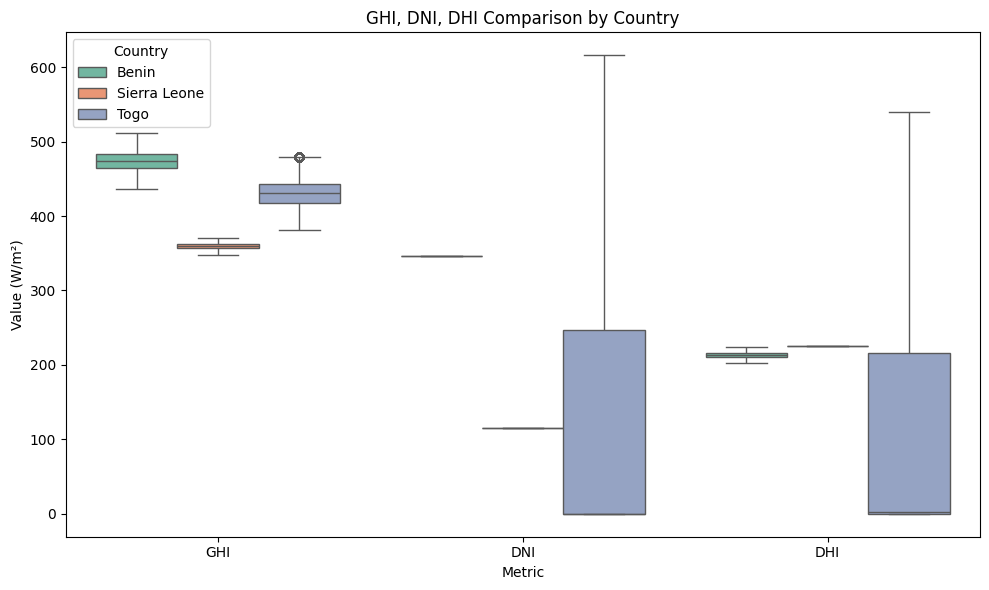

In [2]:
df1['Country'] = 'Benin'
df2['Country'] = 'Sierra Leone'
df3['Country'] = 'Togo'

metrics = ['GHI', 'DNI', 'DHI']
df1_long = df1[metrics + ['Country']].melt(id_vars='Country', var_name='Metric', value_name='Value')
df2_long = df2[metrics + ['Country']].melt(id_vars='Country', var_name='Metric', value_name='Value')
df3_long = df3[metrics + ['Country']].melt(id_vars='Country', var_name='Metric', value_name='Value')

df_long = pd.concat([df1_long, df2_long, df3_long], ignore_index=True)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Metric', y='Value', hue='Country', data=df_long, palette='Set2')
plt.title('GHI, DNI, DHI Comparison by Country')
plt.xlabel('Metric')
plt.ylabel('Value (W/m²)')
plt.legend(title='Country')
plt.tight_layout()
plt.show()


In [4]:

# Define the metrics and countries
metrics = ['GHI', 'DNI', 'DHI']
countries = ['Benin', 'Sierra Leone', 'Togo']
dataframes = [df1, df2, df3]

summary = {}

for df, country in zip(dataframes, countries):
    stats = df[metrics].agg(['mean', 'median', 'std'])
    summary[country] = stats

summary_df = pd.concat(summary, axis=1)

summary_df.columns = summary_df.columns.swaplevel(0, 1)
summary_df = summary_df.sort_index(axis=1, level=0)

pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)
print(summary_df.round(2))


           DHI                         DNI                          GHI  \
         Benin Sierra Leone    Togo  Benin Sierra Leone    Togo   Benin   
mean    213.45        225.0  115.72  345.7        115.3  139.86  474.13   
median  213.40        225.0    2.50  345.7        115.3    0.00  474.20   
std       7.82          0.0  154.36    0.0          0.0  224.28   26.11   

                             
       Sierra Leone    Togo  
mean         359.52  430.30  
median       359.50  430.30  
std            8.02   33.66  


In [5]:
from scipy.stats import f_oneway, kruskal

ghi_benin = df1['GHI']
ghi_sierra = df2['GHI']
ghi_togo = df3['GHI']

# Run one-way ANOVA
anova_result = f_oneway(ghi_benin, ghi_sierra, ghi_togo)
print("One-way ANOVA result:")
print(f"F-statistic = {anova_result.statistic:.4f}, p-value = {anova_result.pvalue:.4f}")

One-way ANOVA result:
F-statistic = 2806161.5163, p-value = 0.0000


A markdown cell with 3 bullet points summarizing what stands out (e.g., “Country X shows highest median GHI but also greatest variability”).

* Sierra Leone has the highest mean in DHI.

* Benin has the highest median in DNI.

* Togo shows the greatest variability (standard deviation) in GHI.

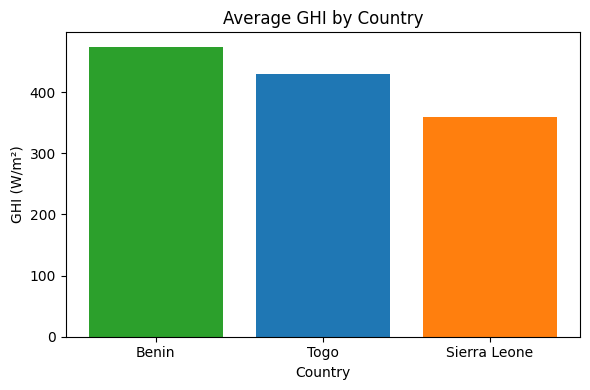

In [7]:
import matplotlib.pyplot as plt

avg_ghi = {
    'Benin': df1['GHI'].mean(),
    'Sierra Leone': df2['GHI'].mean(),
    'Togo': df3['GHI'].mean()
}

avg_ghi_sorted = dict(sorted(avg_ghi.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(6, 4))
plt.bar(avg_ghi_sorted.keys(), avg_ghi_sorted.values(), color=['#2ca02c', '#1f77b4', '#ff7f0e'])
plt.title('Average GHI by Country')
plt.ylabel('GHI (W/m²)')
plt.xlabel('Country')
plt.tight_layout()
plt.show()
